What exactly is in the dataset we want to see?

In [4]:
from pathlib import Path

DATA_ROOT = Path("../data/raw/JPEGImages")

print(DATA_ROOT.resolve())

for path in DATA_ROOT.rglob("*"):
    print(path)
    

G:\VSrepos\repos\cellvision\data\raw\JPEGImages
..\data\raw\JPEGImages\BloodImage_00000.jpg
..\data\raw\JPEGImages\BloodImage_00001.jpg
..\data\raw\JPEGImages\BloodImage_00002.jpg
..\data\raw\JPEGImages\BloodImage_00003.jpg
..\data\raw\JPEGImages\BloodImage_00004.jpg
..\data\raw\JPEGImages\BloodImage_00005.jpg
..\data\raw\JPEGImages\BloodImage_00006.jpg
..\data\raw\JPEGImages\BloodImage_00007.jpg
..\data\raw\JPEGImages\BloodImage_00008.jpg
..\data\raw\JPEGImages\BloodImage_00009.jpg
..\data\raw\JPEGImages\BloodImage_00010.jpg
..\data\raw\JPEGImages\BloodImage_00011.jpg
..\data\raw\JPEGImages\BloodImage_00012.jpg
..\data\raw\JPEGImages\BloodImage_00013.jpg
..\data\raw\JPEGImages\BloodImage_00014.jpg
..\data\raw\JPEGImages\BloodImage_00015.jpg
..\data\raw\JPEGImages\BloodImage_00016.jpg
..\data\raw\JPEGImages\BloodImage_00017.jpg
..\data\raw\JPEGImages\BloodImage_00018.jpg
..\data\raw\JPEGImages\BloodImage_00019.jpg
..\data\raw\JPEGImages\BloodImage_00020.jpg
..\data\raw\JPEGImages\Blood

In [5]:

from pathlib import Path

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

images = [
    path
    for path in DATA_ROOT.rglob("*")
    if path.suffix.lower() in image_extensions
]

print(f"Total Images: {len(images)}")


Total Images: 364


Now we want to normaize image dimensions

In [6]:
from PIL import Image
from collections import Counter

dimensions = []

for image_path in images:
    try:
        with Image.open(image_path) as img:
            dimensions.append(img.size)
    except Exception as e:
        print(f"Could not read {image_path}: {e}")

dimension_counts = Counter(dimensions)

dimension_counts.most_common(10)


[((640, 480), 364)]

Detecting corrupt or invalid images.

In [7]:
invalid_images = []
for image_path in images:
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception:
        invalid_images.append(image_path)

print(f"Invalid images: {len(invalid_images)}")

Invalid images: 0


We want to visualize Data sample images. 

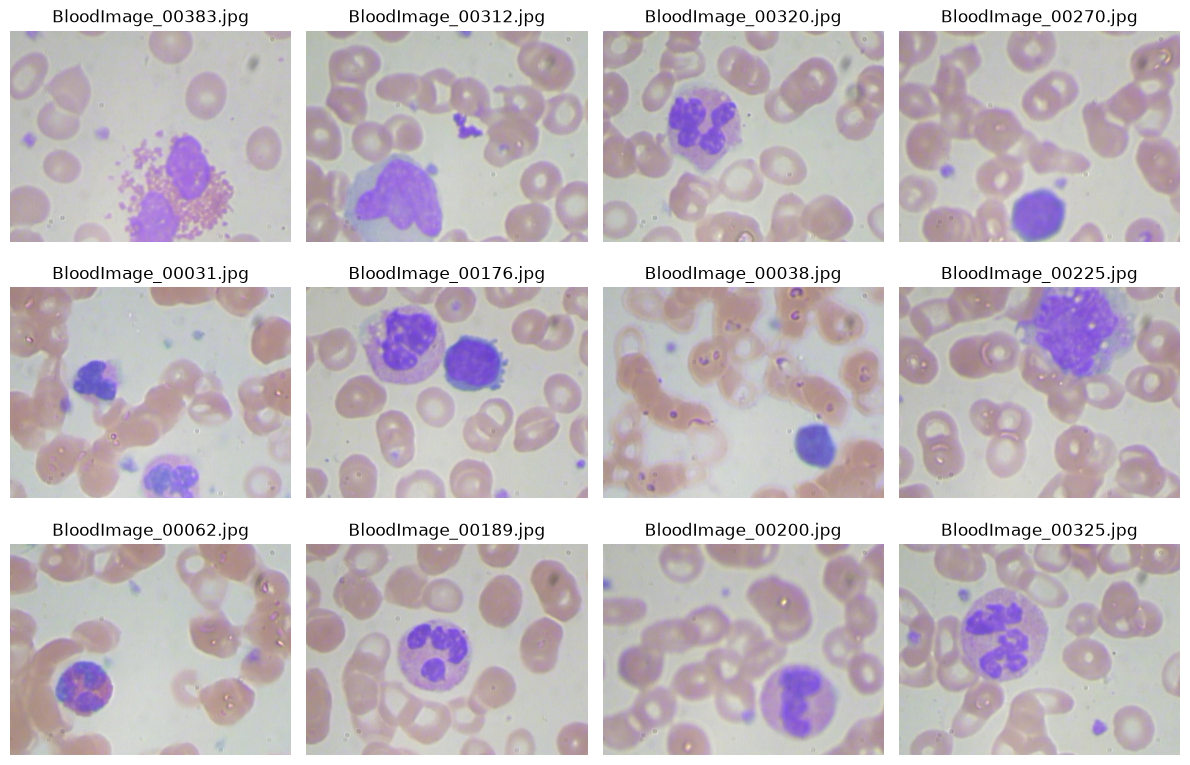

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_images = random.sample(images, min(12, len(images)))

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.name)

plt.tight_layout()
plt.show()

Annotations to get determination of dataset representations.
class: RBC
x: 120
y: 80
width: 35
height: 35

Ending View is similar to below:

CellVision Dataset Report
────────────────────────────

Dataset:
BCCD

Images:
XXXX

Readable:
XXXX

Corrupt:
0

Image dimensions:
640 × 480: XXXX
...

Annotations:
XXXX

Classes:
RBC
WBC
Platelet

Objects:
RBC:       XXXX
WBC:        XXX
Platelet:   XXX